In [11]:
import os
import sys

os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("Crime Data Analysis and Prediction")
    .master("local[*]")
    .config("spark.python.worker.reuse", "true")
    .getOrCreate()
)

print("Python:", sys.version)
print("Spark:", spark.version)

Python: 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]
Spark: 4.0.4


In [12]:
print("Kernel is working!")

Kernel is working!


In [13]:
data = [
    ("THEFT", "District 1"),
    ("BATTERY", "District 2"),
    ("THEFT", "District 1"),
    ("ROBBERY", "District 7")
]

columns = ["Crime_Type", "District"]

test_df = spark.createDataFrame(data, columns)

test_df.show()

+----------+----------+
|Crime_Type|  District|
+----------+----------+
|     THEFT|District 1|
|   BATTERY|District 2|
|     THEFT|District 1|
|   ROBBERY|District 7|
+----------+----------+



In [14]:
test_df.groupBy("Crime_Type").count().show()

+----------+-----+
|Crime_Type|count|
+----------+-----+
|     THEFT|    2|
|   BATTERY|    1|
|   ROBBERY|    1|
+----------+-----+



# 1. Dataset Loading
## Loading the Chicago Crime Dataset using Apache Spark

In [15]:
crime_df = spark.read.csv(
    "Crimes_-_2001_to_Present.csv",
    header=True,
    inferSchema=True
)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [16]:
crime_df.printSchema()

root
 |-- ID: integer (nullable = true)
 |-- Case Number: string (nullable = true)
 |-- Date: string (nullable = true)
 |-- Block: string (nullable = true)
 |-- IUCR: string (nullable = true)
 |-- Primary Type: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Location Description: string (nullable = true)
 |-- Arrest: boolean (nullable = true)
 |-- Domestic: boolean (nullable = true)
 |-- Beat: integer (nullable = true)
 |-- District: integer (nullable = true)
 |-- Ward: integer (nullable = true)
 |-- Community Area: integer (nullable = true)
 |-- FBI Code: string (nullable = true)
 |-- X Coordinate: integer (nullable = true)
 |-- Y Coordinate: integer (nullable = true)
 |-- Year: integer (nullable = true)
 |-- Updated On: string (nullable = true)
 |-- Latitude: double (nullable = true)
 |-- Longitude: double (nullable = true)
 |-- Location: string (nullable = true)



In [17]:
total_records = crime_df.count()

print("Total crime records:", total_records)

Total crime records: 774667


In [18]:
crime_df.show(5, truncate=False)

+--------+-----------+----------------------+---------------------+----+------------+-----------------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+----------------------+------------+-------------+-----------------------------+
|ID      |Case Number|Date                  |Block                |IUCR|Primary Type|Description            |Location Description|Arrest|Domestic|Beat|District|Ward|Community Area|FBI Code|X Coordinate|Y Coordinate|Year|Updated On            |Latitude    |Longitude    |Location                     |
+--------+-----------+----------------------+---------------------+----+------------+-----------------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+----------------------+------------+-------------+-----------------------------+
|10224738|HY411648   |09/05/2015 01:30:00 PM|043XX S WOOD ST      |0486|BATTERY     |DOMESTIC BAT

# 2. Data Understanding and Quality Analysis
## 2.1 Dataset Dimensions

In [19]:
# Number of rows
num_rows = crime_df.count()

# Number of columns
num_columns = len(crime_df.columns)

print("Number of rows:", num_rows)
print("Number of columns:", num_columns)

Number of rows: 774667
Number of columns: 22


## 2.2 Dataset Columns


In [20]:
for i, column in enumerate(crime_df.columns, start=1):
    print(f"{i}. {column}")

1. ID
2. Case Number
3. Date
4. Block
5. IUCR
6. Primary Type
7. Description
8. Location Description
9. Arrest
10. Domestic
11. Beat
12. District
13. Ward
14. Community Area
15. FBI Code
16. X Coordinate
17. Y Coordinate
18. Year
19. Updated On
20. Latitude
21. Longitude
22. Location


## 2.3 Dataset Schema

In [21]:
crime_df.printSchema()

root
 |-- ID: integer (nullable = true)
 |-- Case Number: string (nullable = true)
 |-- Date: string (nullable = true)
 |-- Block: string (nullable = true)
 |-- IUCR: string (nullable = true)
 |-- Primary Type: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Location Description: string (nullable = true)
 |-- Arrest: boolean (nullable = true)
 |-- Domestic: boolean (nullable = true)
 |-- Beat: integer (nullable = true)
 |-- District: integer (nullable = true)
 |-- Ward: integer (nullable = true)
 |-- Community Area: integer (nullable = true)
 |-- FBI Code: string (nullable = true)
 |-- X Coordinate: integer (nullable = true)
 |-- Y Coordinate: integer (nullable = true)
 |-- Year: integer (nullable = true)
 |-- Updated On: string (nullable = true)
 |-- Latitude: double (nullable = true)
 |-- Longitude: double (nullable = true)
 |-- Location: string (nullable = true)



## 2.4 Sample Records

In [22]:
crime_df.show(10, truncate=False)

+--------+-----------+----------------------+-----------------------+----+------------------+-----------------------------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+----------------------+------------+-------------+-----------------------------+
|ID      |Case Number|Date                  |Block                  |IUCR|Primary Type      |Description                        |Location Description|Arrest|Domestic|Beat|District|Ward|Community Area|FBI Code|X Coordinate|Y Coordinate|Year|Updated On            |Latitude    |Longitude    |Location                     |
+--------+-----------+----------------------+-----------------------+----+------------------+-----------------------------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+----------------------+------------+-------------+-----------------------------+
|10224738|HY411648   |09/05/2015 01:3

## 2.5 Missing-Value Analysis

In [23]:
from pyspark.sql.functions import col, sum, when, count

missing_values = crime_df.select([
    sum(when(col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in crime_df.columns
])

missing_values.show(truncate=False)

+---+-----------+----+-----+----+------------+-----------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+----------+--------+---------+--------+
|ID |Case Number|Date|Block|IUCR|Primary Type|Description|Location Description|Arrest|Domestic|Beat|District|Ward|Community Area|FBI Code|X Coordinate|Y Coordinate|Year|Updated On|Latitude|Longitude|Location|
+---+-----------+----+-----+----+------------+-----------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+----------+--------+---------+--------+
|0  |0          |0   |0    |0   |0           |0          |2379                |0     |0       |0   |1       |197 |189           |0       |4408        |4408        |0   |0         |4408    |4408     |4408    |
+---+-----------+----+-----+----+------------+-----------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+

## 2.6 Missing-Value Percentage

In [24]:
from pyspark.sql.functions import col, sum, when, round

total_records = crime_df.count()

missing_percentage = crime_df.select([
    round(
        sum(when(col(c).isNull(), 1).otherwise(0)) / total_records * 100,
        2
    ).alias(c)
    for c in crime_df.columns
])

missing_percentage.show(truncate=False)

+---+-----------+----+-----+----+------------+-----------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+----------+--------+---------+--------+
|ID |Case Number|Date|Block|IUCR|Primary Type|Description|Location Description|Arrest|Domestic|Beat|District|Ward|Community Area|FBI Code|X Coordinate|Y Coordinate|Year|Updated On|Latitude|Longitude|Location|
+---+-----------+----+-----+----+------------+-----------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+----------+--------+---------+--------+
|0.0|0.0        |0.0 |0.0  |0.0 |0.0         |0.0        |0.31                |0.0   |0.0     |0.0 |0.0     |0.03|0.02          |0.0     |0.57        |0.57        |0.0 |0.0       |0.57    |0.57     |0.57    |
+---+-----------+----+-----+----+------------+-----------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+

In [25]:
from pyspark.sql.functions import col, sum, when
import builtins

total_records = crime_df.count()

missing_data = crime_df.select([
    sum(when(col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in crime_df.columns
])

missing_rows = missing_data.collect()[0]

missing_summary = []

for column, count_missing in zip(crime_df.columns, missing_rows):
    if count_missing > 0:
        percentage = (count_missing / total_records) * 100

        missing_summary.append(
            (column, int(count_missing), builtins.round(percentage, 2))
        )

missing_df = spark.createDataFrame(
    missing_summary,
    ["Column", "Missing_Count", "Missing_Percentage"]
)

missing_df.orderBy(
    col("Missing_Percentage").desc()
).show(truncate=False)

+--------------------+-------------+------------------+
|Column              |Missing_Count|Missing_Percentage|
+--------------------+-------------+------------------+
|X Coordinate        |4408         |0.57              |
|Y Coordinate        |4408         |0.57              |
|Latitude            |4408         |0.57              |
|Longitude           |4408         |0.57              |
|Location            |4408         |0.57              |
|Location Description|2379         |0.31              |
|Ward                |197          |0.03              |
|Community Area      |189          |0.02              |
|District            |1            |0.0               |
+--------------------+-------------+------------------+



## 2.7 Approximate Record Analysis

In [26]:
from pyspark.sql.functions import approx_count_distinct

total_records = crime_df.count()

approx_unique_ids = crime_df.select(
    approx_count_distinct("ID", rsd=0.01).alias("approx_unique_ids")
).collect()[0]["approx_unique_ids"]

print("Total records:", total_records)
print("Approximate unique IDs:", approx_unique_ids)

Total records: 774667
Approximate unique IDs: 770149


## 2.8 Categorical Value Analysis
### Crime Types

In [27]:
from pyspark.sql.functions import col
crime_df.groupBy("Primary Type") \
    .count() \
    .orderBy(col("count").desc()) \
    .show(truncate=False)

+--------------------------------+------+
|Primary Type                    |count |
+--------------------------------+------+
|THEFT                           |179286|
|BATTERY                         |143561|
|CRIMINAL DAMAGE                 |87182 |
|ASSAULT                         |54034 |
|DECEPTIVE PRACTICE              |53739 |
|OTHER OFFENSE                   |50726 |
|NARCOTICS                       |40955 |
|BURGLARY                        |39386 |
|ROBBERY                         |33031 |
|MOTOR VEHICLE THEFT             |32321 |
|CRIMINAL TRESPASS               |19337 |
|WEAPONS VIOLATION               |12320 |
|OFFENSE INVOLVING CHILDREN      |6557  |
|PUBLIC PEACE VIOLATION          |4822  |
|CRIM SEXUAL ASSAULT             |4163  |
|INTERFERENCE WITH PUBLIC OFFICER|3258  |
|SEX OFFENSE                     |2894  |
|PROSTITUTION                    |2361  |
|ARSON                           |1308  |
|LIQUOR LAW VIOLATION            |667   |
+--------------------------------+

### Arrest Distribution

In [28]:
crime_df.groupBy("Arrest") \
    .count() \
    .orderBy(col("count").desc()) \
    .show()

+------+------+
|Arrest| count|
+------+------+
| false|614742|
|  true|159925|
+------+------+



In [29]:
crime_df.groupBy("Domestic") \
    .count() \
    .orderBy(col("count").desc()) \
    .show()

+--------+------+
|Domestic| count|
+--------+------+
|   false|649395|
|    true|125272|
+--------+------+



In [30]:
crime_df.select(
    "Latitude",
    "Longitude",
    "X Coordinate",
    "Y Coordinate"
).summary().show()

+-------+-------------------+-------------------+------------------+-----------------+
|summary|           Latitude|          Longitude|      X Coordinate|     Y Coordinate|
+-------+-------------------+-------------------+------------------+-----------------+
|  count|             770259|             770259|            770259|           770259|
|   mean|   41.8437698115155| -87.67100698428713|1164730.1752358621|1886361.534687683|
| stddev|0.08598663940275693|0.05933598029881922|16304.337616976281|31265.35767577841|
|    min|       36.619446395|      -91.686565684|                 0|                0|
|    25%|       41.769231153|      -87.713647558|           1152991|          1859294|
|    50%|       41.863577921|      -87.664619276|           1166464|          1893537|
|    75%|       41.905704685|      -87.627874384|           1176436|          1908873|
|    max|       42.022671246|      -87.524529465|           1205119|          1951535|
+-------+-------------------+--------------

# 3. Data Cleaning

## 3.1 Handling Missing Categorical Values

In [31]:
from pyspark.sql.functions import col

crime_clean_df = crime_df.fillna({
    "Location Description": "Unknown"
})

print("Categorical missing values handled.")

Categorical missing values handled.


In [32]:
crime_clean_df.select(
    "Location Description",
    "District",
    "Ward",
    "Community Area"
).show(10, truncate=False)

+--------------------+--------+----+--------------+
|Location Description|District|Ward|Community Area|
+--------------------+--------+----+--------------+
|RESIDENCE           |9       |12  |61            |
|CTA BUS             |15      |29  |25            |
|RESIDENCE           |6       |8   |44            |
|SIDEWALK            |14      |35  |21            |
|APARTMENT           |15      |28  |25            |
|RESIDENCE           |6       |21  |71            |
|RESIDENCE-GARAGE    |14      |32  |24            |
|GROCERY FOOD STORE  |10      |25  |31            |
|STREET              |12      |27  |27            |
|Unknown             |8       |15  |63            |
+--------------------+--------+----+--------------+
only showing top 10 rows


In [33]:
from pyspark.sql.functions import sum, when

crime_clean_df.select([
    sum(
        when(col(c).isNull(), 1).otherwise(0)
    ).alias(c)
    for c in [
        "Location Description",
        "District",
        "Ward",
        "Community Area"
    ]
]).show()

+--------------------+--------+----+--------------+
|Location Description|District|Ward|Community Area|
+--------------------+--------+----+--------------+
|                   0|       1| 197|           189|
+--------------------+--------+----+--------------+



In [34]:
original_count = crime_df.count()
cleaned_count = crime_clean_df.count()

print("Original records:", original_count)
print("Cleaned records:", cleaned_count)
print("Records removed:", original_count - cleaned_count)

Original records: 774667
Cleaned records: 774667
Records removed: 0


In [35]:
crime_clean_df.printSchema()

root
 |-- ID: integer (nullable = true)
 |-- Case Number: string (nullable = true)
 |-- Date: string (nullable = true)
 |-- Block: string (nullable = true)
 |-- IUCR: string (nullable = true)
 |-- Primary Type: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Location Description: string (nullable = false)
 |-- Arrest: boolean (nullable = true)
 |-- Domestic: boolean (nullable = true)
 |-- Beat: integer (nullable = true)
 |-- District: integer (nullable = true)
 |-- Ward: integer (nullable = true)
 |-- Community Area: integer (nullable = true)
 |-- FBI Code: string (nullable = true)
 |-- X Coordinate: integer (nullable = true)
 |-- Y Coordinate: integer (nullable = true)
 |-- Year: integer (nullable = true)
 |-- Updated On: string (nullable = true)
 |-- Latitude: double (nullable = true)
 |-- Longitude: double (nullable = true)
 |-- Location: string (nullable = true)



## 3.2 Converting Date to Timestamp

In [36]:
from pyspark.sql.functions import to_timestamp

crime_clean_df = crime_clean_df.withColumn(
    "Date",
    to_timestamp("Date", "MM/dd/yyyy hh:mm:ss a")
)

crime_clean_df.select("Date").show(10, truncate=False)

+-------------------+
|Date               |
+-------------------+
|2015-09-05 13:30:00|
|2015-09-04 11:30:00|
|2018-09-01 00:01:00|
|2015-09-05 12:45:00|
|2015-09-05 13:00:00|
|2015-09-05 10:55:00|
|2015-09-04 18:00:00|
|2015-09-05 13:00:00|
|2015-09-05 11:30:00|
|2016-05-01 00:25:00|
+-------------------+
only showing top 10 rows


### 3.3 Extracting Temporal Features

In [37]:
from pyspark.sql.functions import year, month, dayofmonth, dayofweek, hour

crime_clean_df = (
    crime_clean_df
    .withColumn("Crime_Year", year("Date"))
    .withColumn("Crime_Month", month("Date"))
    .withColumn("Crime_Day", dayofmonth("Date"))
    .withColumn("Crime_DayOfWeek", dayofweek("Date"))
    .withColumn("Crime_Hour", hour("Date"))
)

crime_clean_df.select(
    "Date",
    "Crime_Year",
    "Crime_Month",
    "Crime_Day",
    "Crime_DayOfWeek",
    "Crime_Hour"
).show(10, truncate=False)

+-------------------+----------+-----------+---------+---------------+----------+
|Date               |Crime_Year|Crime_Month|Crime_Day|Crime_DayOfWeek|Crime_Hour|
+-------------------+----------+-----------+---------+---------------+----------+
|2015-09-05 13:30:00|2015      |9          |5        |7              |13        |
|2015-09-04 11:30:00|2015      |9          |4        |6              |11        |
|2018-09-01 00:01:00|2018      |9          |1        |7              |0         |
|2015-09-05 12:45:00|2015      |9          |5        |7              |12        |
|2015-09-05 13:00:00|2015      |9          |5        |7              |13        |
|2015-09-05 10:55:00|2015      |9          |5        |7              |10        |
|2015-09-04 18:00:00|2015      |9          |4        |6              |18        |
|2015-09-05 13:00:00|2015      |9          |5        |7              |13        |
|2015-09-05 11:30:00|2015      |9          |5        |7              |11        |
|2016-05-01 00:2

In [38]:
crime_clean_df.select(
    "Crime_Year",
    "Crime_Month",
    "Crime_Day",
    "Crime_DayOfWeek",
    "Crime_Hour"
).summary().show()

+-------+------------------+------------------+-----------------+------------------+------------------+
|summary|        Crime_Year|       Crime_Month|        Crime_Day|   Crime_DayOfWeek|        Crime_Hour|
+-------+------------------+------------------+-----------------+------------------+------------------+
|  count|            774667|            774667|           774667|            774667|            774667|
|   mean|2016.4872984133829| 6.693553488143938|15.72401302753312|4.0326695212265395|13.139142366978328|
| stddev|1.0784051549390543|3.3992114239132416| 8.82764033303948| 2.004041917408191| 6.553807372327884|
|    min|              2001|                 1|                1|                 1|                 0|
|    25%|              2016|                 4|                8|                 2|                 9|
|    50%|              2016|                 7|               16|                 4|                14|
|    75%|              2017|                10|               23

In [39]:
print("Records after feature engineering:", crime_clean_df.count())

Records after feature engineering: 774667


### 3.4 Day of Week Name

In [40]:
from pyspark.sql.functions import date_format

crime_clean_df = crime_clean_df.withColumn(
    "Day_Name",
    date_format("Date", "EEEE")
)

crime_clean_df.select(
    "Date",
    "Crime_DayOfWeek",
    "Day_Name"
).show(10, truncate=False)

+-------------------+---------------+--------+
|Date               |Crime_DayOfWeek|Day_Name|
+-------------------+---------------+--------+
|2015-09-05 13:30:00|7              |Saturday|
|2015-09-04 11:30:00|6              |Friday  |
|2018-09-01 00:01:00|7              |Saturday|
|2015-09-05 12:45:00|7              |Saturday|
|2015-09-05 13:00:00|7              |Saturday|
|2015-09-05 10:55:00|7              |Saturday|
|2015-09-04 18:00:00|6              |Friday  |
|2015-09-05 13:00:00|7              |Saturday|
|2015-09-05 11:30:00|7              |Saturday|
|2016-05-01 00:25:00|1              |Sunday  |
+-------------------+---------------+--------+
only showing top 10 rows


In [41]:
from pyspark.sql.functions import col, sum, when

date_null_count = crime_clean_df.select(
    sum(when(col("Date").isNull(), 1).otherwise(0)).alias("Invalid_Date_Count")
).collect()[0]["Invalid_Date_Count"]

print("Invalid/NULL dates:", date_null_count)

Invalid/NULL dates: 0


In [42]:
crime_clean_df.groupBy("Crime_Year") \
    .count() \
    .orderBy("Crime_Year") \
    .show(100)

+----------+------+
|Crime_Year| count|
+----------+------+
|      2001|   202|
|      2002|    16|
|      2003|    14|
|      2004|     7|
|      2005|    28|
|      2006|    26|
|      2007|    30|
|      2008|    52|
|      2009|    70|
|      2010|   136|
|      2011|   166|
|      2012|   246|
|      2013|   363|
|      2014|   878|
|      2015|131568|
|      2016|261368|
|      2017|260078|
|      2018|107110|
|      2019|  5941|
|      2020|  5045|
|      2021|   875|
|      2022|    11|
|      2023|   437|
+----------+------+



In [43]:
crime_clean_df.groupBy("Crime_Month") \
    .count() \
    .orderBy("Crime_Month") \
    .show()

+-----------+-----+
|Crime_Month|count|
+-----------+-----+
|          1|61654|
|          2|54098|
|          3|66661|
|          4|64607|
|          5|49545|
|          6|50063|
|          7|63065|
|          8|96377|
|          9|73210|
|         10|72706|
|         11|61682|
|         12|60999|
+-----------+-----+



In [44]:
crime_clean_df.groupBy("Day_Name") \
    .count() \
    .orderBy(col("count").desc()) \
    .show()

+---------+------+
| Day_Name| count|
+---------+------+
|   Friday|116310|
| Saturday|112283|
| Thursday|110514|
|   Monday|110503|
|  Tuesday|108646|
|   Sunday|108341|
|Wednesday|108070|
+---------+------+



In [45]:
from pyspark.sql.functions import col, sum, when

date_null_count = crime_clean_df.select(
    sum(when(col("Date").isNull(), 1).otherwise(0)).alias("Invalid_Date_Count")
).collect()[0]["Invalid_Date_Count"]

print("Invalid/NULL dates:", date_null_count)

Invalid/NULL dates: 0


In [46]:
print("Total records:", crime_clean_df.count())

Total records: 774667


# 4. Exploratory Data Analysis

## 4.1 Crime Trend by Year

In [47]:
yearly_crime = (
    crime_clean_df
    .groupBy("Crime_Year")
    .count()
    .orderBy("Crime_Year")
)

yearly_crime.show(100)

+----------+------+
|Crime_Year| count|
+----------+------+
|      2001|   202|
|      2002|    16|
|      2003|    14|
|      2004|     7|
|      2005|    28|
|      2006|    26|
|      2007|    30|
|      2008|    52|
|      2009|    70|
|      2010|   136|
|      2011|   166|
|      2012|   246|
|      2013|   363|
|      2014|   878|
|      2015|131568|
|      2016|261368|
|      2017|260078|
|      2018|107110|
|      2019|  5941|
|      2020|  5045|
|      2021|   875|
|      2022|    11|
|      2023|   437|
+----------+------+



In [48]:
yearly_crime.orderBy(
    col("count").desc()
).show(10)

+----------+------+
|Crime_Year| count|
+----------+------+
|      2016|261368|
|      2017|260078|
|      2015|131568|
|      2018|107110|
|      2019|  5941|
|      2020|  5045|
|      2014|   878|
|      2021|   875|
|      2023|   437|
|      2013|   363|
+----------+------+
only showing top 10 rows


In [49]:
yearly_crime.orderBy(
    col("count").asc()
).show(10)

+----------+-----+
|Crime_Year|count|
+----------+-----+
|      2004|    7|
|      2022|   11|
|      2003|   14|
|      2002|   16|
|      2006|   26|
|      2005|   28|
|      2007|   30|
|      2008|   52|
|      2009|   70|
|      2010|  136|
+----------+-----+
only showing top 10 rows


In [50]:
yearly_crime.orderBy("Crime_Year").show(100)

+----------+------+
|Crime_Year| count|
+----------+------+
|      2001|   202|
|      2002|    16|
|      2003|    14|
|      2004|     7|
|      2005|    28|
|      2006|    26|
|      2007|    30|
|      2008|    52|
|      2009|    70|
|      2010|   136|
|      2011|   166|
|      2012|   246|
|      2013|   363|
|      2014|   878|
|      2015|131568|
|      2016|261368|
|      2017|260078|
|      2018|107110|
|      2019|  5941|
|      2020|  5045|
|      2021|   875|
|      2022|    11|
|      2023|   437|
+----------+------+



In [51]:
crime_clean_df.select(
    "Crime_Year"
).distinct().orderBy("Crime_Year").show(100)

+----------+
|Crime_Year|
+----------+
|      2001|
|      2002|
|      2003|
|      2004|
|      2005|
|      2006|
|      2007|
|      2008|
|      2009|
|      2010|
|      2011|
|      2012|
|      2013|
|      2014|
|      2015|
|      2016|
|      2017|
|      2018|
|      2019|
|      2020|
|      2021|
|      2022|
|      2023|
+----------+



In [52]:
crime_clean_df.select("Date") \
    .orderBy(col("Date").desc()) \
    .show(20, truncate=False)

+-------------------+
|Date               |
+-------------------+
|2023-03-30 23:51:00|
|2023-03-30 23:50:00|
|2023-03-30 23:49:00|
|2023-03-30 23:44:00|
|2023-03-30 23:35:00|
|2023-03-30 23:31:00|
|2023-03-30 23:31:00|
|2023-03-30 23:30:00|
|2023-03-30 23:22:00|
|2023-03-30 23:15:00|
|2023-03-30 23:05:00|
|2023-03-30 23:00:00|
|2023-03-30 23:00:00|
|2023-03-30 23:00:00|
|2023-03-30 23:00:00|
|2023-03-30 23:00:00|
|2023-03-30 22:59:00|
|2023-03-30 22:50:00|
|2023-03-30 22:46:00|
|2023-03-30 22:30:00|
+-------------------+
only showing top 20 rows


In [53]:
crime_type_counts = (
    crime_clean_df
    .groupBy("Primary Type")
    .count()
    .orderBy(col("count").desc())
)

crime_type_counts.show(50, truncate=False)

+---------------------------------+------+
|Primary Type                     |count |
+---------------------------------+------+
|THEFT                            |179286|
|BATTERY                          |143561|
|CRIMINAL DAMAGE                  |87182 |
|ASSAULT                          |54034 |
|DECEPTIVE PRACTICE               |53739 |
|OTHER OFFENSE                    |50726 |
|NARCOTICS                        |40955 |
|BURGLARY                         |39386 |
|ROBBERY                          |33031 |
|MOTOR VEHICLE THEFT              |32321 |
|CRIMINAL TRESPASS                |19337 |
|WEAPONS VIOLATION                |12320 |
|OFFENSE INVOLVING CHILDREN       |6557  |
|PUBLIC PEACE VIOLATION           |4822  |
|CRIM SEXUAL ASSAULT              |4163  |
|INTERFERENCE WITH PUBLIC OFFICER |3258  |
|SEX OFFENSE                      |2894  |
|PROSTITUTION                     |2361  |
|ARSON                            |1308  |
|LIQUOR LAW VIOLATION             |667   |
|GAMBLING  

In [54]:
crime_type_counts.limit(10).show(truncate=False)

+-------------------+------+
|Primary Type       |count |
+-------------------+------+
|THEFT              |179286|
|BATTERY            |143561|
|CRIMINAL DAMAGE    |87182 |
|ASSAULT            |54034 |
|DECEPTIVE PRACTICE |53739 |
|OTHER OFFENSE      |50726 |
|NARCOTICS          |40955 |
|BURGLARY           |39386 |
|ROBBERY            |33031 |
|MOTOR VEHICLE THEFT|32321 |
+-------------------+------+



In [55]:
from pyspark.sql.functions import round

crime_type_percentage = (
    crime_type_counts
    .withColumn(
        "Percentage",
        round(
            (col("count") / total_records) * 100,
            2
        )
    )
)

crime_type_percentage.show(50, truncate=False)

+---------------------------------+------+----------+
|Primary Type                     |count |Percentage|
+---------------------------------+------+----------+
|THEFT                            |179286|23.14     |
|BATTERY                          |143561|18.53     |
|CRIMINAL DAMAGE                  |87182 |11.25     |
|ASSAULT                          |54034 |6.98      |
|DECEPTIVE PRACTICE               |53739 |6.94      |
|OTHER OFFENSE                    |50726 |6.55      |
|NARCOTICS                        |40955 |5.29      |
|BURGLARY                         |39386 |5.08      |
|ROBBERY                          |33031 |4.26      |
|MOTOR VEHICLE THEFT              |32321 |4.17      |
|CRIMINAL TRESPASS                |19337 |2.5       |
|WEAPONS VIOLATION                |12320 |1.59      |
|OFFENSE INVOLVING CHILDREN       |6557  |0.85      |
|PUBLIC PEACE VIOLATION           |4822  |0.62      |
|CRIM SEXUAL ASSAULT              |4163  |0.54      |
|INTERFERENCE WITH PUBLIC OF

In [56]:
monthly_crime = (
    crime_clean_df
    .groupBy("Crime_Month")
    .count()
    .orderBy("Crime_Month")
)

monthly_crime.show()

+-----------+-----+
|Crime_Month|count|
+-----------+-----+
|          1|61654|
|          2|54098|
|          3|66661|
|          4|64607|
|          5|49545|
|          6|50063|
|          7|63065|
|          8|96377|
|          9|73210|
|         10|72706|
|         11|61682|
|         12|60999|
+-----------+-----+



In [57]:
from pyspark.sql.functions import date_format

monthly_crime = (
    crime_clean_df
    .groupBy("Crime_Month")
    .agg(
        count("*").alias("Crime_Count")
    )
    .orderBy("Crime_Month")
)

monthly_crime.show()

+-----------+-----------+
|Crime_Month|Crime_Count|
+-----------+-----------+
|          1|      61654|
|          2|      54098|
|          3|      66661|
|          4|      64607|
|          5|      49545|
|          6|      50063|
|          7|      63065|
|          8|      96377|
|          9|      73210|
|         10|      72706|
|         11|      61682|
|         12|      60999|
+-----------+-----------+



In [58]:
hourly_crime = (
    crime_clean_df
    .groupBy("Crime_Hour")
    .count()
    .orderBy("Crime_Hour")
)

hourly_crime.show(24)

+----------+-----+
|Crime_Hour|count|
+----------+-----+
|         0|37009|
|         1|23050|
|         2|19876|
|         3|16562|
|         4|12985|
|         5|11434|
|         6|13689|
|         7|18944|
|         8|27425|
|         9|35960|
|        10|34398|
|        11|35236|
|        12|46294|
|        13|37686|
|        14|39145|
|        15|42057|
|        16|41356|
|        17|42043|
|        18|45054|
|        19|43998|
|        20|41637|
|        21|38988|
|        22|38019|
|        23|31822|
+----------+-----+



In [59]:
hourly_crime.orderBy(
    col("count").desc()
).show(10)

+----------+-----+
|Crime_Hour|count|
+----------+-----+
|        12|46294|
|        18|45054|
|        19|43998|
|        15|42057|
|        17|42043|
|        20|41637|
|        16|41356|
|        14|39145|
|        21|38988|
|        22|38019|
+----------+-----+
only showing top 10 rows


In [60]:
district_crime = (
    crime_clean_df
    .groupBy("District")
    .count()
    .orderBy(col("count").desc())
)

district_crime.show(20)

+--------+-----+
|District|count|
+--------+-----+
|      11|53585|
|       8|48954|
|       6|47293|
|       4|43379|
|       1|41814|
|      25|41507|
|       7|41259|
|      18|40272|
|      12|38742|
|       3|36583|
|      10|35987|
|       9|34887|
|      19|34843|
|       5|33734|
|       2|33239|
|      15|31244|
|      14|28507|
|      16|26534|
|      22|24596|
|      17|22636|
+--------+-----+
only showing top 20 rows


In [61]:
arrest_analysis = (
    crime_clean_df
    .groupBy("Arrest")
    .count()
    .orderBy(col("count").desc())
)

arrest_analysis.show()

+------+------+
|Arrest| count|
+------+------+
| false|614742|
|  true|159925|
+------+------+



In [62]:
arrest_percentage = (
    arrest_analysis
    .withColumn(
        "Percentage",
        round((col("count") / total_records) * 100, 2)
    )
)

arrest_percentage.show()

+------+------+----------+
|Arrest| count|Percentage|
+------+------+----------+
| false|614742|     79.36|
|  true|159925|     20.64|
+------+------+----------+



In [63]:
arrest_by_type = (
    crime_clean_df
    .groupBy("Primary Type")
    .agg(
        count("*").alias("Total_Crimes"),
        sum(when(col("Arrest") == True, 1).otherwise(0)).alias("Arrests")
    )
    .withColumn(
        "Arrest_Rate",
        round((col("Arrests") / col("Total_Crimes")) * 100, 2)
    )
    .orderBy(col("Arrest_Rate").desc())
)

arrest_by_type.show(30, truncate=False)

+---------------------------------+------------+-------+-----------+
|Primary Type                     |Total_Crimes|Arrests|Arrest_Rate|
+---------------------------------+------------+-------+-----------+
|GAMBLING                         |584         |584    |100.0      |
|PUBLIC INDECENCY                 |30          |30     |100.0      |
|PROSTITUTION                     |2361        |2361   |100.0      |
|NARCOTICS                        |40955       |40933  |99.95      |
|LIQUOR LAW VIOLATION             |667         |665    |99.7       |
|CONCEALED CARRY LICENSE VIOLATION|179         |172    |96.09      |
|INTERFERENCE WITH PUBLIC OFFICER |3258        |3095   |95.0       |
|HOMICIDE                         |19          |18     |94.74      |
|OBSCENITY                        |201         |161    |80.1       |
|WEAPONS VIOLATION                |12320       |9278   |75.31      |
|PUBLIC PEACE VIOLATION           |4822        |3376   |70.01      |
|OTHER NARCOTIC VIOLATION         

In [64]:
#Geographic Analysis
geo_analysis = crime_clean_df.select(
    sum(
        when(
            col("Latitude").isNotNull() &
            col("Longitude").isNotNull(),
            1
        ).otherwise(0)
    ).alias("Valid_Geographic_Records"),

    sum(
        when(
            col("Latitude").isNull() |
            col("Longitude").isNull(),
            1
        ).otherwise(0)
    ).alias("Missing_Geographic_Records")
)

geo_analysis.show()

+------------------------+--------------------------+
|Valid_Geographic_Records|Missing_Geographic_Records|
+------------------------+--------------------------+
|                  770259|                      4408|
+------------------------+--------------------------+



In [65]:
#Crime Concentration by Community Area
community_crime = (
    crime_clean_df
    .filter(col("Community Area").isNotNull())
    .groupBy("Community Area")
    .count()
    .orderBy(col("count").desc())
)

community_crime.show(20)

+--------------+-----+
|Community Area|count|
+--------------+-----+
|            25|46514|
|             8|32631|
|            32|28286|
|            28|26074|
|            29|25784|
|            43|24841|
|            23|23212|
|            24|22924|
|            71|22035|
|            67|20394|
|            49|19762|
|            69|19115|
|            44|18329|
|            68|18102|
|            66|16923|
|             6|16911|
|            26|16368|
|            22|14857|
|            27|14433|
|            46|13795|
+--------------+-----+
only showing top 20 rows


In [66]:
#Crime Concentration by Beat
beat_crime = (
    crime_clean_df
    .filter(col("Beat").isNotNull())
    .groupBy("Beat")
    .count()
    .orderBy(col("count").desc())
)

beat_crime.show(20)

+----+-----+
|Beat|count|
+----+-----+
|1834| 8140|
| 421| 6296|
| 112| 6012|
| 111| 5898|
|1831| 5849|
| 511| 5674|
| 423| 5561|
| 624| 5499|
|1533| 5430|
|1011| 5249|
| 122| 5243|
|1112| 5211|
|1132| 5199|
| 621| 4996|
|1522| 4808|
|1833| 4779|
|1121| 4725|
| 632| 4658|
| 612| 4638|
| 123| 4576|
+----+-----+
only showing top 20 rows


# 5. Data Visualization

## 5.1 Crime Trend by Year

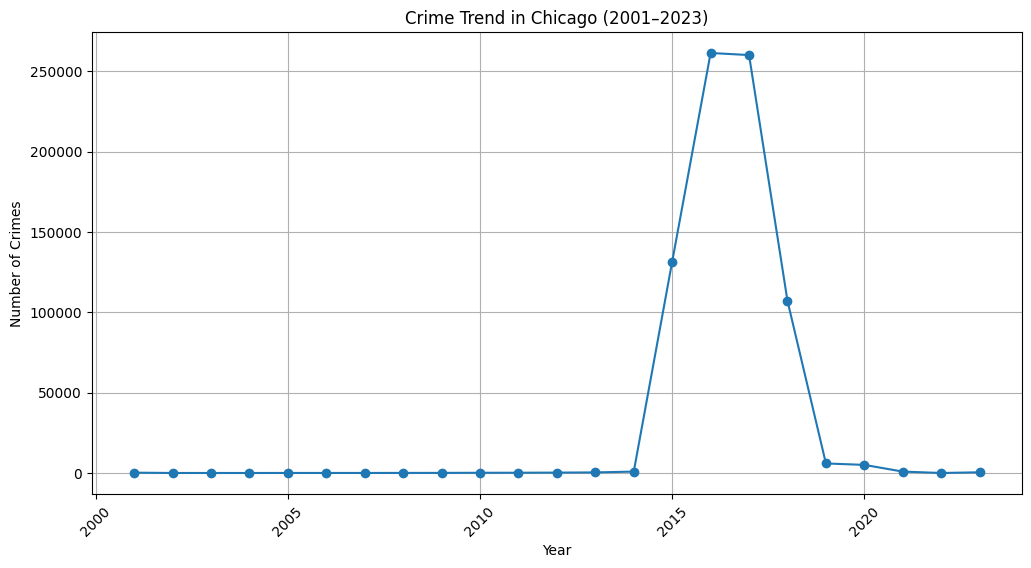

In [67]:
import matplotlib.pyplot as plt

yearly_pd = yearly_crime.toPandas()

plt.figure(figsize=(12, 6))

plt.plot(
    yearly_pd["Crime_Year"],
    yearly_pd["count"],
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Number of Crimes")
plt.title("Crime Trend in Chicago (2001–2023)")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

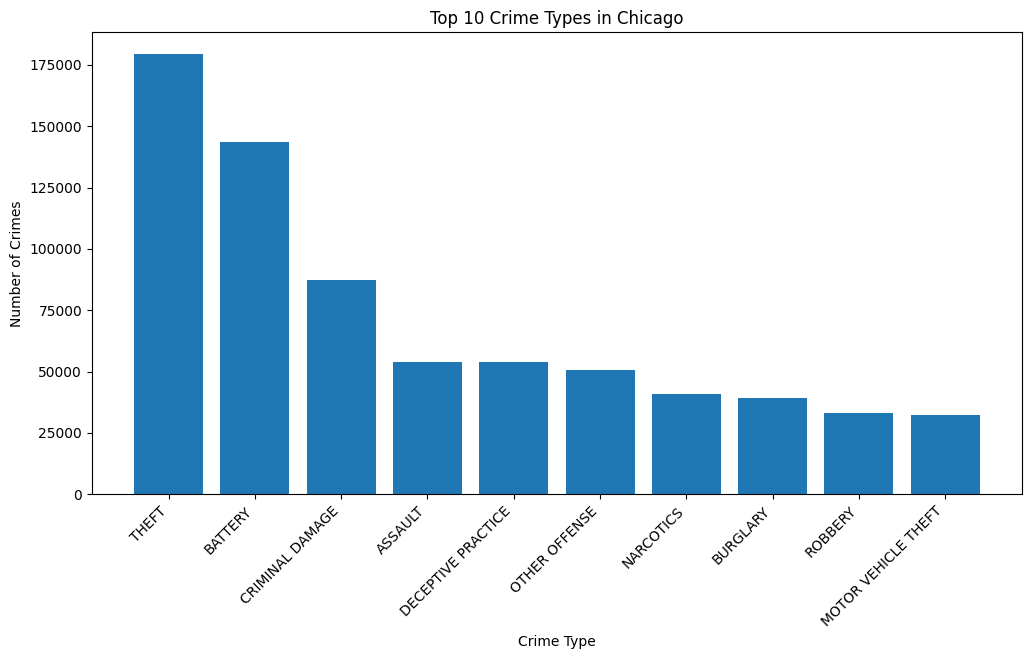

In [68]:
top_crimes_pd = crime_type_counts.limit(10).toPandas()

plt.figure(figsize=(12, 6))

plt.bar(
    top_crimes_pd["Primary Type"],
    top_crimes_pd["count"]
)

plt.xlabel("Crime Type")
plt.ylabel("Number of Crimes")
plt.title("Top 10 Crime Types in Chicago")
plt.xticks(rotation=45, ha="right")

plt.show()

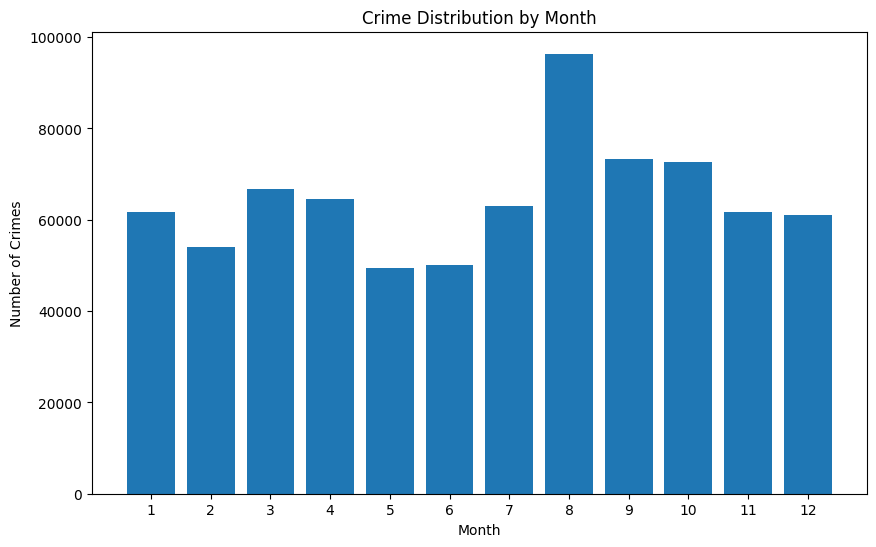

In [69]:
monthly_pd = monthly_crime.toPandas()

plt.figure(figsize=(10, 6))

plt.bar(
    monthly_pd["Crime_Month"],
    monthly_pd["Crime_Count"]
)

plt.xlabel("Month")
plt.ylabel("Number of Crimes")
plt.title("Crime Distribution by Month")
plt.xticks(range(1, 13))

plt.show()

In [70]:
from pyspark.sql.functions import when

day_crime = (
    crime_clean_df
    .groupBy("Crime_DayOfWeek", "Day_Name")
    .count()
    .orderBy("Crime_DayOfWeek")
)

day_crime.show()

+---------------+---------+------+
|Crime_DayOfWeek| Day_Name| count|
+---------------+---------+------+
|              1|   Sunday|108341|
|              2|   Monday|110503|
|              3|  Tuesday|108646|
|              4|Wednesday|108070|
|              5| Thursday|110514|
|              6|   Friday|116310|
|              7| Saturday|112283|
+---------------+---------+------+



In [71]:
day_pd = day_crime.toPandas()

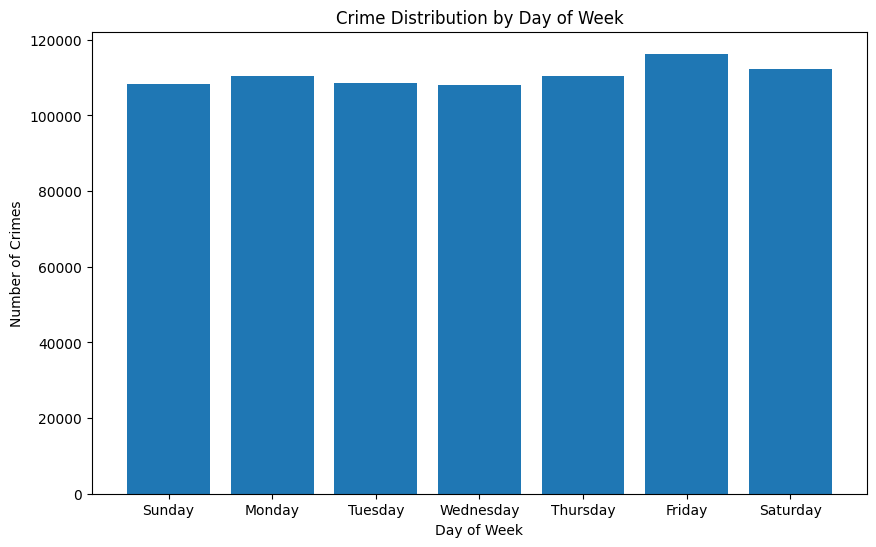

In [72]:
plt.figure(figsize=(10, 6))

plt.bar(
    day_pd["Day_Name"],
    day_pd["count"]
)

plt.xlabel("Day of Week")
plt.ylabel("Number of Crimes")
plt.title("Crime Distribution by Day of Week")

plt.show()

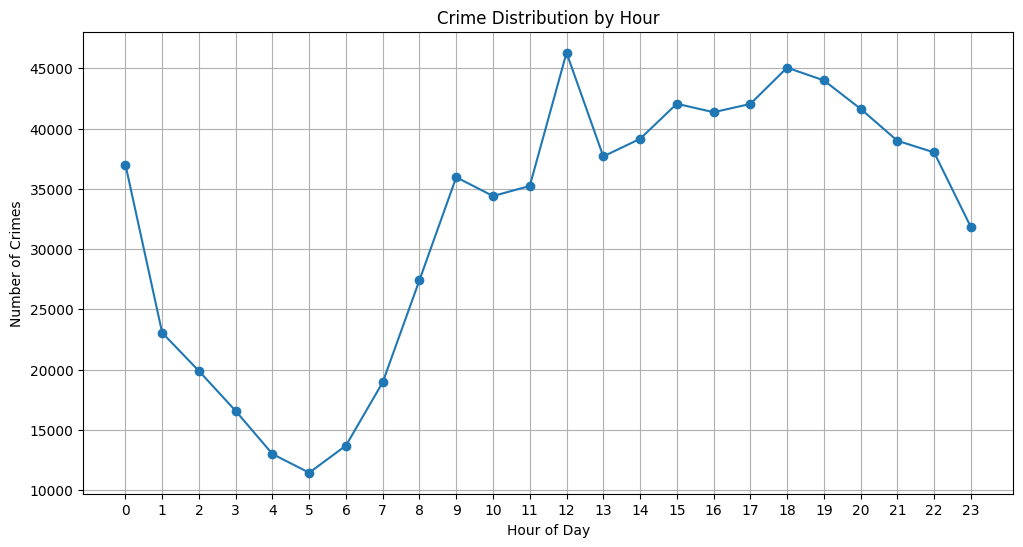

In [73]:
hourly_pd = hourly_crime.toPandas()

plt.figure(figsize=(12, 6))

plt.plot(
    hourly_pd["Crime_Hour"],
    hourly_pd["count"],
    marker="o"
)

plt.xlabel("Hour of Day")
plt.ylabel("Number of Crimes")
plt.title("Crime Distribution by Hour")

plt.xticks(range(0, 24))
plt.grid(True)

plt.show()

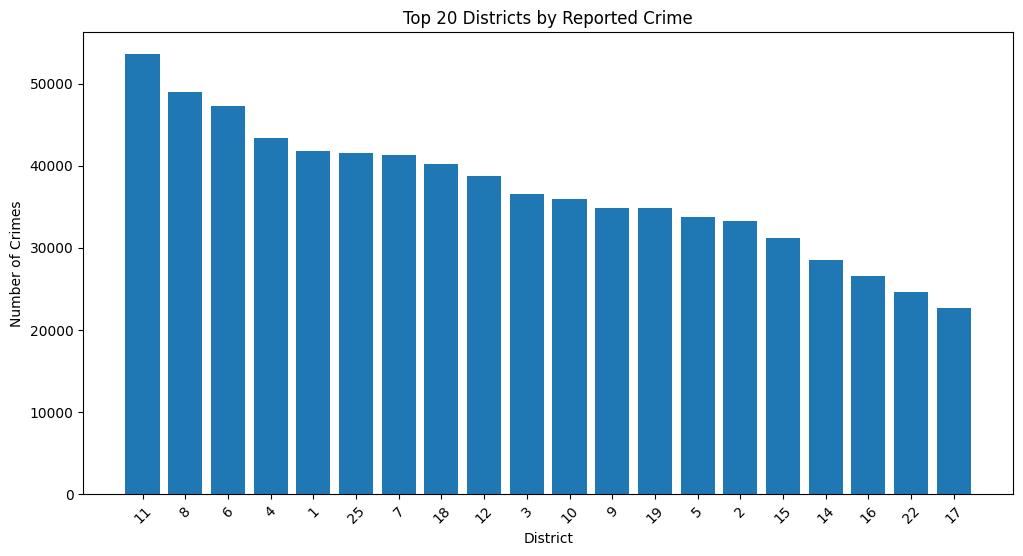

In [74]:
district_pd = district_crime.limit(20).toPandas()

plt.figure(figsize=(12, 6))

plt.bar(
    district_pd["District"].astype(str),
    district_pd["count"]
)

plt.xlabel("District")
plt.ylabel("Number of Crimes")
plt.title("Top 20 Districts by Reported Crime")

plt.xticks(rotation=45)

plt.show()

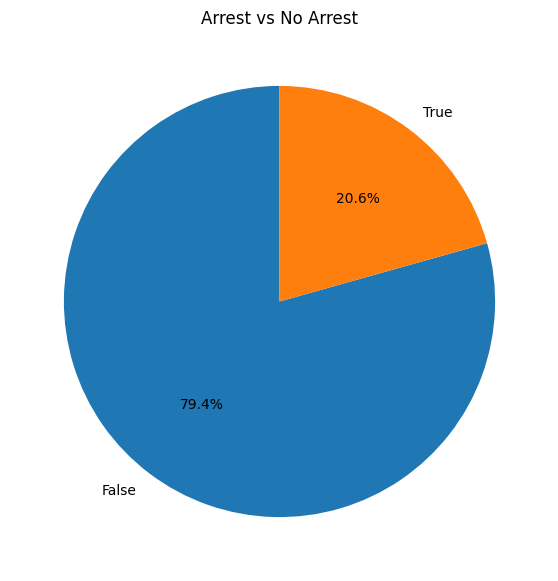

In [75]:
#arrest distribution
arrest_pd = arrest_percentage.toPandas()

plt.figure(figsize=(7, 7))

plt.pie(
    arrest_pd["Percentage"],
    labels=arrest_pd["Arrest"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Arrest vs No Arrest")
plt.show()

In [76]:
arrest_rate_pd = (
    arrest_by_type
    .filter(col("Total_Crimes") >= 1000)
    .orderBy(col("Arrest_Rate").desc())
    .limit(15)
    .toPandas()
)

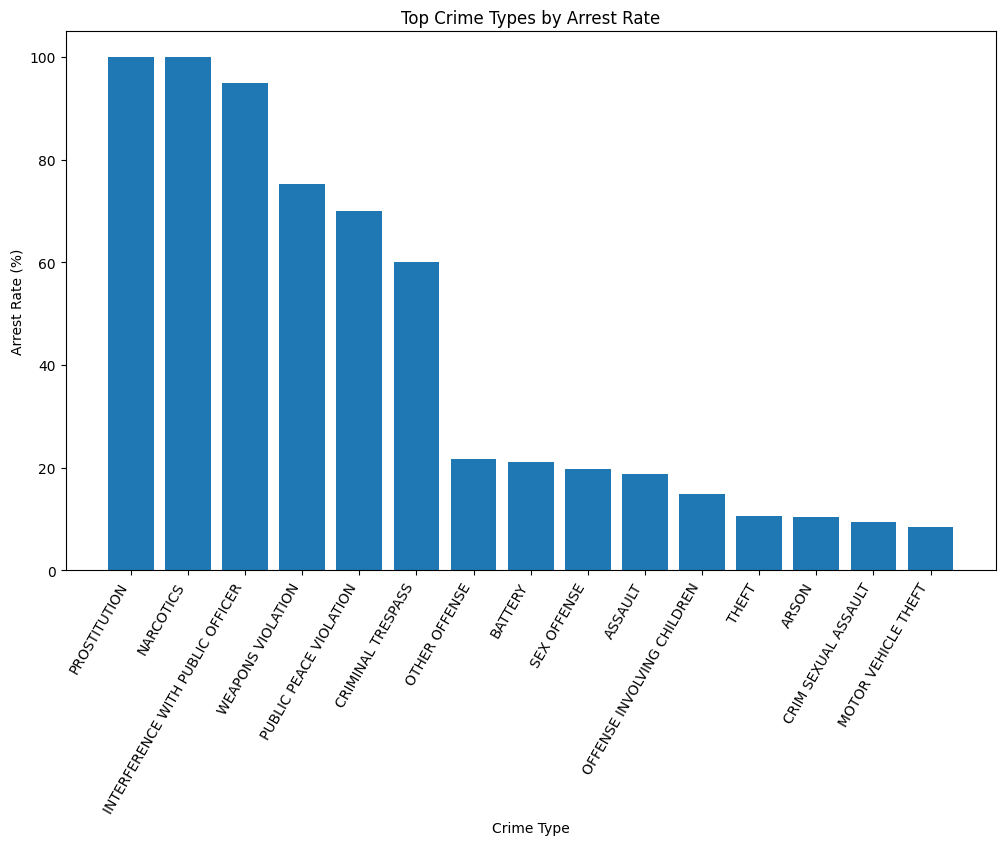

In [77]:
plt.figure(figsize=(12, 7))

plt.bar(
    arrest_rate_pd["Primary Type"],
    arrest_rate_pd["Arrest_Rate"]
)

plt.xlabel("Crime Type")
plt.ylabel("Arrest Rate (%)")
plt.title("Top Crime Types by Arrest Rate")

plt.xticks(rotation=60, ha="right")

plt.show()

In [78]:
geo_sample = (
    crime_clean_df
    .filter(
        col("Latitude").isNotNull() &
        col("Longitude").isNotNull()
    )
    .sample(
        withReplacement=False,
        fraction=0.01,
        seed=42
    )
    .select("Latitude", "Longitude")
)

In [79]:
geo_pd = geo_sample.toPandas()

print("Sampled records:", len(geo_pd))

Sampled records: 7753


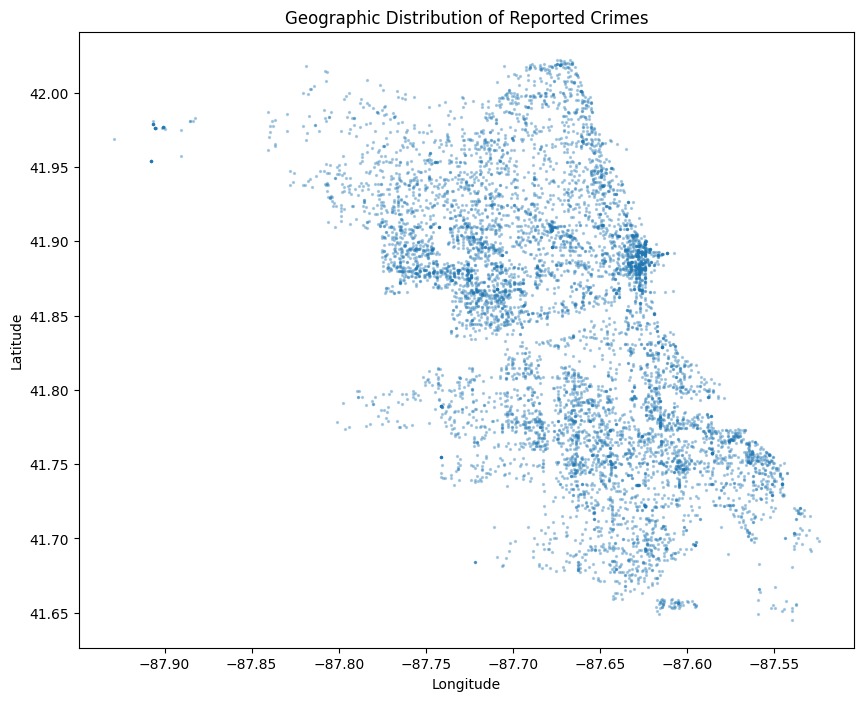

In [80]:
plt.figure(figsize=(10, 8))

plt.scatter(
    geo_pd["Longitude"],
    geo_pd["Latitude"],
    s=2,
    alpha=0.3
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographic Distribution of Reported Crimes")

plt.show()

In [81]:
ml_df = crime_clean_df.select(
    "Crime_Year",
    "Crime_Month",
    "Crime_Hour",
    "Crime_DayOfWeek",
    "District",
    "Ward",
    "Community Area",
    "Beat",
    "Arrest",
    "Domestic",
    "Latitude",
    "Longitude",
    "Primary Type"
)

ml_df.show(5)

+----------+-----------+----------+---------------+--------+----+--------------+----+------+--------+------------+-------------+------------+
|Crime_Year|Crime_Month|Crime_Hour|Crime_DayOfWeek|District|Ward|Community Area|Beat|Arrest|Domestic|    Latitude|    Longitude|Primary Type|
+----------+-----------+----------+---------------+--------+----+--------------+----+------+--------+------------+-------------+------------+
|      2015|          9|        13|              7|       9|  12|            61| 924| false|    true|41.815117282|-87.669999562|     BATTERY|
|      2015|          9|        11|              6|      15|  29|            25|1511| false|   false|41.895080471|-87.765400451|       THEFT|
|      2018|          9|         0|              7|       6|   8|            44| 631| false|    true|        NULL|         NULL|       THEFT|
|      2015|          9|        12|              7|      14|  35|            21|1412|  true|   false|41.937405765|-87.716649687|   NARCOTICS|
|     

In [82]:
ml_df.printSchema()

root
 |-- Crime_Year: integer (nullable = true)
 |-- Crime_Month: integer (nullable = true)
 |-- Crime_Hour: integer (nullable = true)
 |-- Crime_DayOfWeek: integer (nullable = true)
 |-- District: integer (nullable = true)
 |-- Ward: integer (nullable = true)
 |-- Community Area: integer (nullable = true)
 |-- Beat: integer (nullable = true)
 |-- Arrest: boolean (nullable = true)
 |-- Domestic: boolean (nullable = true)
 |-- Latitude: double (nullable = true)
 |-- Longitude: double (nullable = true)
 |-- Primary Type: string (nullable = true)



In [83]:
from pyspark.sql.functions import col, sum, when

ml_missing = ml_df.select(
    [
        sum(
            when(col(c).isNull(), 1).otherwise(0)
        ).alias(c)
        for c in ml_df.columns
    ]
)

ml_missing.show(truncate=False)

+----------+-----------+----------+---------------+--------+----+--------------+----+------+--------+--------+---------+------------+
|Crime_Year|Crime_Month|Crime_Hour|Crime_DayOfWeek|District|Ward|Community Area|Beat|Arrest|Domestic|Latitude|Longitude|Primary Type|
+----------+-----------+----------+---------------+--------+----+--------------+----+------+--------+--------+---------+------------+
|0         |0          |0         |0              |1       |197 |189           |0   |0     |0       |4408    |4408     |0           |
+----------+-----------+----------+---------------+--------+----+--------------+----+------+--------+--------+---------+------------+



In [84]:
ml_df.filter(
    col("Primary Type").isNull()
).count()

0

In [85]:
ml_df.select("Primary Type").distinct().count()

34

In [86]:
from pyspark.sql.functions import percentile_approx

medians = ml_df.select(
    percentile_approx("Latitude", 0.5).alias("Latitude_Median"),
    percentile_approx("Longitude", 0.5).alias("Longitude_Median"),
    percentile_approx("District", 0.5).alias("District_Median")
).collect()[0]

print("Latitude median:", medians["Latitude_Median"])
print("Longitude median:", medians["Longitude_Median"])
print("District median:", medians["District_Median"])

Latitude median: 41.863577921
Longitude median: -87.664619276
District median: 10


In [87]:
latitude_median = medians["Latitude_Median"]
longitude_median = medians["Longitude_Median"]
district_median = medians["District_Median"]

ml_df = ml_df.fillna({
    "Latitude": latitude_median,
    "Longitude": longitude_median,
    "District": district_median,
    "Ward": -1,
    "Community Area": -1
})

In [88]:
ml_df.select(
    [
        sum(
            when(col(c).isNull(), 1).otherwise(0)
        ).alias(c)
        for c in ml_df.columns
    ]
).show()

+----------+-----------+----------+---------------+--------+----+--------------+----+------+--------+--------+---------+------------+
|Crime_Year|Crime_Month|Crime_Hour|Crime_DayOfWeek|District|Ward|Community Area|Beat|Arrest|Domestic|Latitude|Longitude|Primary Type|
+----------+-----------+----------+---------------+--------+----+--------------+----+------+--------+--------+---------+------------+
|         0|          0|         0|              0|       0|   0|             0|   0|     0|       0|       0|        0|           0|
+----------+-----------+----------+---------------+--------+----+--------------+----+------+--------+--------+---------+------------+



In [89]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
day_indexer = StringIndexer(
    inputCol="Crime_DayOfWeek",
    outputCol="Day_Index",
    handleInvalid="keep"
)

district_indexer = StringIndexer(
    inputCol="District",
    outputCol="District_Index",
    handleInvalid="keep"
)

ward_indexer = StringIndexer(
    inputCol="Ward",
    outputCol="Ward_Index",
    handleInvalid="keep"
)

community_indexer = StringIndexer(
    inputCol="Community Area",
    outputCol="Community_Index",
    handleInvalid="keep"
)

beat_indexer = StringIndexer(
    inputCol="Beat",
    outputCol="Beat_Index",
    handleInvalid="keep"
)

arrest_indexer = StringIndexer(
    inputCol="Arrest",
    outputCol="Arrest_Index",
    handleInvalid="keep"
)

domestic_indexer = StringIndexer(
    inputCol="Domestic",
    outputCol="Domestic_Index",
    handleInvalid="keep"
)
label_indexer = StringIndexer(
    inputCol="Primary Type",
    outputCol="label",
    handleInvalid="keep"
)

In [90]:
assembler = VectorAssembler(
    inputCols=[
        "Crime_Year",
        "Crime_Month",
        "Crime_Hour",
        "Day_Index",
        "District_Index",
        "Ward_Index",
        "Community_Index",
        "Beat_Index",
        "Arrest_Index",
        "Domestic_Index",
        "Latitude",
        "Longitude"
    ],
    outputCol="features"
)

In [91]:
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml import Pipeline
rf = RandomForestClassifier(
    labelCol="label",
    featuresCol="features",
    numTrees=50,
    maxDepth=10,
    seed=42
)
pipeline = Pipeline(
    stages=[
        day_indexer,
        district_indexer,
        ward_indexer,
        community_indexer,
        beat_indexer,
        arrest_indexer,
        domestic_indexer,
        label_indexer,
        assembler,
        rf
    ]
)

In [92]:
train_df, test_df = ml_df.randomSplit(
    [0.8, 0.2],
    seed=42
)

print("Training records:", train_df.count())
print("Testing records:", test_df.count())

Training records: 619571
Testing records: 155096


In [93]:
train_df, test_df = ml_df.randomSplit(
    [0.8, 0.2],
    seed=42
)

print("Training records:", train_df.count())
print("Testing records:", test_df.count())

Training records: 619571
Testing records: 155096


In [94]:
print(crime_df.columns)

['ID', 'Case Number', 'Date', 'Block', 'IUCR', 'Primary Type', 'Description', 'Location Description', 'Arrest', 'Domestic', 'Beat', 'District', 'Ward', 'Community Area', 'FBI Code', 'X Coordinate', 'Y Coordinate', 'Year', 'Updated On', 'Latitude', 'Longitude', 'Location']


In [95]:
from pyspark.sql.functions import (
    col, to_timestamp, year, month, hour, dayofweek, when
)

ml_df = crime_df.withColumn(
    "Date_Parsed",
    to_timestamp(
        col("Date"),
        "MM/dd/yyyy hh:mm:ss a"
    )
)

ml_df = ml_df.select(
    "Date_Parsed",
    "District",
    "Ward",
    "Community Area",
    "Beat",
    "Arrest",
    "Domestic",
    "Latitude",
    "Longitude",
    "Primary Type"
)

ml_df = (
    ml_df
    .withColumn("Crime_Year", year("Date_Parsed"))
    .withColumn("Crime_Month", month("Date_Parsed"))
    .withColumn("Crime_Hour", hour("Date_Parsed"))
    .withColumn("Crime_DayOfWeek", dayofweek("Date_Parsed"))
)

ml_df.printSchema()

root
 |-- Date_Parsed: timestamp (nullable = true)
 |-- District: integer (nullable = true)
 |-- Ward: integer (nullable = true)
 |-- Community Area: integer (nullable = true)
 |-- Beat: integer (nullable = true)
 |-- Arrest: boolean (nullable = true)
 |-- Domestic: boolean (nullable = true)
 |-- Latitude: double (nullable = true)
 |-- Longitude: double (nullable = true)
 |-- Primary Type: string (nullable = true)
 |-- Crime_Year: integer (nullable = true)
 |-- Crime_Month: integer (nullable = true)
 |-- Crime_Hour: integer (nullable = true)
 |-- Crime_DayOfWeek: integer (nullable = true)



In [96]:
ml_df.select(
    "Date_Parsed",
    "Crime_Year",
    "Crime_Month",
    "Crime_Hour",
    "Crime_DayOfWeek"
).show(5)

+-------------------+----------+-----------+----------+---------------+
|        Date_Parsed|Crime_Year|Crime_Month|Crime_Hour|Crime_DayOfWeek|
+-------------------+----------+-----------+----------+---------------+
|2015-09-05 13:30:00|      2015|          9|        13|              7|
|2015-09-04 11:30:00|      2015|          9|        11|              6|
|2018-09-01 00:01:00|      2018|          9|         0|              7|
|2015-09-05 12:45:00|      2015|          9|        12|              7|
|2015-09-05 13:00:00|      2015|          9|        13|              7|
+-------------------+----------+-----------+----------+---------------+
only showing top 5 rows


In [97]:
ml_df = (
    ml_df
    .withColumn(
        "Arrest_Num",
        when(col("Arrest") == True, 1).otherwise(0)
    )
    .withColumn(
        "Domestic_Num",
        when(col("Domestic") == True, 1).otherwise(0)
    )
)

In [98]:
from pyspark.ml.feature import StringIndexer

label_indexer = StringIndexer(
    inputCol="Primary Type",
    outputCol="label"
)

label_model = label_indexer.fit(ml_df)

ml_df = label_model.transform(ml_df)

In [99]:
ml_df.select(
    "Primary Type",
    "label"
).show(10)

+------------------+-----+
|      Primary Type|label|
+------------------+-----+
|           BATTERY|  1.0|
|             THEFT|  0.0|
|             THEFT|  0.0|
|         NARCOTICS|  6.0|
|           ASSAULT|  3.0|
|          BURGLARY|  7.0|
|          BURGLARY|  7.0|
|             THEFT|  0.0|
|           ROBBERY|  8.0|
|DECEPTIVE PRACTICE|  4.0|
+------------------+-----+
only showing top 10 rows


In [100]:
ml_df.select(
    "Crime_Year",
    "Crime_Month",
    "Crime_Hour",
    "Crime_DayOfWeek",
    "District",
    "Ward",
    "Community Area",
    "Beat",
    "Arrest_Num",
    "Domestic_Num",
    "Latitude",
    "Longitude",
    "label"
).show(5)

+----------+-----------+----------+---------------+--------+----+--------------+----+----------+------------+------------+-------------+-----+
|Crime_Year|Crime_Month|Crime_Hour|Crime_DayOfWeek|District|Ward|Community Area|Beat|Arrest_Num|Domestic_Num|    Latitude|    Longitude|label|
+----------+-----------+----------+---------------+--------+----+--------------+----+----------+------------+------------+-------------+-----+
|      2015|          9|        13|              7|       9|  12|            61| 924|         0|           1|41.815117282|-87.669999562|  1.0|
|      2015|          9|        11|              6|      15|  29|            25|1511|         0|           0|41.895080471|-87.765400451|  0.0|
|      2018|          9|         0|              7|       6|   8|            44| 631|         0|           1|        NULL|         NULL|  0.0|
|      2015|          9|        12|              7|      14|  35|            21|1412|         1|           0|41.937405765|-87.716649687|  6.0|

In [101]:
from pyspark.ml.feature import VectorAssembler

feature_cols = [
    "Crime_Year",
    "Crime_Month",
    "Crime_Hour",
    "Crime_DayOfWeek",
    "District",
    "Ward",
    "Community Area",
    "Beat",
    "Arrest_Num",
    "Domestic_Num",
    "Latitude",
    "Longitude"
]

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features",
    handleInvalid="keep"
)

assembled_df = assembler.transform(ml_df)

assembled_df.select("features", "label").show(5, truncate=False)

+------------------------------------------------------------------------------+-----+
|features                                                                      |label|
+------------------------------------------------------------------------------+-----+
|[2015.0,9.0,13.0,7.0,9.0,12.0,61.0,924.0,0.0,1.0,41.815117282,-87.669999562]  |1.0  |
|[2015.0,9.0,11.0,6.0,15.0,29.0,25.0,1511.0,0.0,0.0,41.895080471,-87.765400451]|0.0  |
|[2018.0,9.0,0.0,7.0,6.0,8.0,44.0,631.0,0.0,1.0,NaN,NaN]                       |0.0  |
|[2015.0,9.0,12.0,7.0,14.0,35.0,21.0,1412.0,1.0,0.0,41.937405765,-87.716649687]|6.0  |
|[2015.0,9.0,13.0,7.0,15.0,28.0,25.0,1522.0,0.0,1.0,41.881903443,-87.755121152]|3.0  |
+------------------------------------------------------------------------------+-----+
only showing top 5 rows


In [102]:
train_df, test_df = assembled_df.randomSplit(
    [0.8, 0.2],
    seed=42
)

print("Training records:", train_df.count())
print("Testing records:", test_df.count())

Training records: 619571
Testing records: 155096


In [103]:
from pyspark.sql.functions import col

train_df = train_df.filter(
    col("Latitude").isNotNull() &
    col("Longitude").isNotNull()
)

test_df = test_df.filter(
    col("Latitude").isNotNull() &
    col("Longitude").isNotNull()
)

print("Training records:", train_df.count())
print("Testing records:", test_df.count())

Training records: 616013
Testing records: 154246


In [104]:
from pyspark.ml.feature import VectorAssembler

rf_features = [
    "Crime_Year",
    "Crime_Month",
    "Crime_Hour",
    "Crime_DayOfWeek",
    "District",
    "Ward",
    "Community Area",
    "Beat",
    "Arrest_Num",
    "Domestic_Num",
    "Latitude",
    "Longitude"
]

rf_assembler = VectorAssembler(
    inputCols=rf_features,
    outputCol="rf_features"
)

train_rf = rf_assembler.transform(train_df).select(
    "rf_features",
    "label"
)

test_rf = rf_assembler.transform(test_df).select(
    "rf_features",
    "label"
)

train_rf.show(5, truncate=False)

+------------------------------------------------------------------------------+-----+
|rf_features                                                                   |label|
+------------------------------------------------------------------------------+-----+
|[2007.0,6.0,0.0,5.0,16.0,45.0,15.0,1623.0,0.0,0.0,41.963596188,-87.759997717] |12.0 |
|[2008.0,6.0,13.0,4.0,11.0,28.0,28.0,1135.0,0.0,0.0,41.869331608,-87.687091821]|27.0 |
|[2008.0,9.0,20.0,6.0,11.0,28.0,27.0,1135.0,1.0,0.0,41.871049071,-87.697336573]|1.0  |
|[2009.0,9.0,0.0,5.0,10.0,22.0,30.0,1024.0,0.0,1.0,41.847589828,-87.713659288] |14.0 |
|[2009.0,11.0,20.0,4.0,3.0,7.0,43.0,333.0,0.0,1.0,41.759780594,-87.572455541]  |14.0 |
+------------------------------------------------------------------------------+-----+
only showing top 5 rows


In [105]:
from pyspark.sql.functions import col, isnan

train_rf.select(
    *[
        col(c).alias(c)
        for c in ["rf_features", "label"]
    ]
).show(5, truncate=False)

+------------------------------------------------------------------------------+-----+
|rf_features                                                                   |label|
+------------------------------------------------------------------------------+-----+
|[2007.0,6.0,0.0,5.0,16.0,45.0,15.0,1623.0,0.0,0.0,41.963596188,-87.759997717] |12.0 |
|[2008.0,6.0,13.0,4.0,11.0,28.0,28.0,1135.0,0.0,0.0,41.869331608,-87.687091821]|27.0 |
|[2008.0,9.0,20.0,6.0,11.0,28.0,27.0,1135.0,1.0,0.0,41.871049071,-87.697336573]|1.0  |
|[2009.0,9.0,0.0,5.0,10.0,22.0,30.0,1024.0,0.0,1.0,41.847589828,-87.713659288] |14.0 |
|[2009.0,11.0,20.0,4.0,3.0,7.0,43.0,333.0,0.0,1.0,41.759780594,-87.572455541]  |14.0 |
+------------------------------------------------------------------------------+-----+
only showing top 5 rows


In [106]:
print("Training sample:", train_rf.limit(50000).count())

train_rf.limit(50000).select("rf_features", "label").show(10, truncate=False)

Training sample: 50000
+------------------------------------------------------------------------------+-----+
|rf_features                                                                   |label|
+------------------------------------------------------------------------------+-----+
|[2007.0,6.0,0.0,5.0,16.0,45.0,15.0,1623.0,0.0,0.0,41.963596188,-87.759997717] |12.0 |
|[2008.0,6.0,13.0,4.0,11.0,28.0,28.0,1135.0,0.0,0.0,41.869331608,-87.687091821]|27.0 |
|[2008.0,9.0,20.0,6.0,11.0,28.0,27.0,1135.0,1.0,0.0,41.871049071,-87.697336573]|1.0  |
|[2009.0,9.0,0.0,5.0,10.0,22.0,30.0,1024.0,0.0,1.0,41.847589828,-87.713659288] |14.0 |
|[2009.0,11.0,20.0,4.0,3.0,7.0,43.0,333.0,0.0,1.0,41.759780594,-87.572455541]  |14.0 |
|[2010.0,1.0,0.0,6.0,16.0,45.0,15.0,1622.0,0.0,1.0,41.96503178,-87.768375694]  |12.0 |
|[2010.0,1.0,0.0,6.0,7.0,16.0,68.0,724.0,0.0,0.0,41.777801618,-87.653757812]   |4.0  |
|[2010.0,1.0,0.0,6.0,25.0,37.0,25.0,2532.0,0.0,0.0,41.904885987,-87.762701686] |14.0 |
|[2010.0,1.0,0.0,5.0

In [107]:
check_cols = [
    "Crime_Year",
    "Crime_Month",
    "Crime_Hour",
    "Crime_DayOfWeek",
    "District",
    "Ward",
    "Community Area",
    "Beat",
    "Arrest_Num",
    "Domestic_Num",
    "Latitude",
    "Longitude"
]

for c in check_cols:
    count = train_df.filter(
        col(c).isNull() | isnan(col(c))
    ).count()
    print(c, ":", count)

Crime_Year : 0
Crime_Month : 0
Crime_Hour : 0
Crime_DayOfWeek : 0
District : 1
Ward : 0
Community Area : 0
Beat : 0
Arrest_Num : 0
Domestic_Num : 0
Latitude : 0
Longitude : 0


In [108]:
from pyspark.sql.functions import col

train_df = train_df.fillna({
    "District": 0,
    "Ward": 0,
    "Community Area": 0,
    "Beat": 0,
    "Latitude": 0.0,
    "Longitude": 0.0
})

test_df = test_df.fillna({
    "District": 0,
    "Ward": 0,
    "Community Area": 0,
    "Beat": 0,
    "Latitude": 0.0,
    "Longitude": 0.0
})

print("Missing values filled!")

Missing values filled!


In [109]:
from pyspark.sql.functions import isnan, when, count

for c in rf_features:
    print(c, train_df.filter(col(c).isNull() | isnan(col(c))).count())

Crime_Year 0
Crime_Month 0
Crime_Hour 0
Crime_DayOfWeek 0
District 0
Ward 0
Community Area 0
Beat 0
Arrest_Num 0
Domestic_Num 0
Latitude 0
Longitude 0


In [110]:
rf_assembler = VectorAssembler(
    inputCols=rf_features,
    outputCol="rf_features"
)

train_rf = rf_assembler.transform(train_df).select(
    "rf_features",
    "label"
)

test_rf = rf_assembler.transform(test_df).select(
    "rf_features",
    "label"
)

train_rf.show(5, truncate=False)

+------------------------------------------------------------------------------+-----+
|rf_features                                                                   |label|
+------------------------------------------------------------------------------+-----+
|[2007.0,6.0,0.0,5.0,16.0,45.0,15.0,1623.0,0.0,0.0,41.963596188,-87.759997717] |12.0 |
|[2008.0,6.0,13.0,4.0,11.0,28.0,28.0,1135.0,0.0,0.0,41.869331608,-87.687091821]|27.0 |
|[2008.0,9.0,20.0,6.0,11.0,28.0,27.0,1135.0,1.0,0.0,41.871049071,-87.697336573]|1.0  |
|[2009.0,9.0,0.0,5.0,10.0,22.0,30.0,1024.0,0.0,1.0,41.847589828,-87.713659288] |14.0 |
|[2009.0,11.0,20.0,4.0,3.0,7.0,43.0,333.0,0.0,1.0,41.759780594,-87.572455541]  |14.0 |
+------------------------------------------------------------------------------+-----+
only showing top 5 rows


In [111]:
from pyspark.ml.classification import RandomForestClassifier

rf_test = RandomForestClassifier(
    featuresCol="rf_features",
    labelCol="label",
    numTrees=20,
    maxDepth=5,
    maxBins=300,
    seed=42
)

small_train = train_rf.limit(50000)

small_rf_model = rf_test.fit(small_train)

print("Random Forest test training successful!")

Random Forest test training successful!


In [112]:
rf_features = [
    "Crime_Year",
    "Crime_Month",
    "Crime_Hour",
    "Crime_DayOfWeek",
    "District",
    "Ward",
    "Community Area",
    "Beat",
    "Arrest_Num",
    "Domestic_Num",
    "Latitude",
    "Longitude"
]

In [113]:
print(train_df.count())
print(test_df.count())

616013
154246


In [114]:
from pyspark.ml.feature import VectorAssembler

rf_features = [
    "Crime_Year",
    "Crime_Month",
    "Crime_Hour",
    "Crime_DayOfWeek",
    "District",
    "Ward",
    "Community Area",
    "Beat",
    "Arrest_Num",
    "Domestic_Num",
    "Latitude",
    "Longitude"
]

# Check whether features already exists
print("features in train_df:", "features" in train_df.columns)
print("features in test_df:", "features" in test_df.columns)

features in train_df: True
features in test_df: True


In [115]:
train_rf = train_df.select(
    "features",
    "label"
)

test_rf = test_df.select(
    "features",
    "label"
)

print("Random Forest data prepared successfully!")

Random Forest data prepared successfully!


In [116]:
print("Training records:", train_rf.count())
print("Testing records:", test_rf.count())

Training records: 616013
Testing records: 154246


In [117]:
from pyspark.ml.classification import RandomForestClassifier

rf_final = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    numTrees=20,
    maxDepth=8,
    maxBins=128,
    seed=42
)

print("Starting Random Forest training...")

Starting Random Forest training...


In [118]:
from pyspark.sql.functions import col, isnan, when

rf_features = [
    "Crime_Year",
    "Crime_Month",
    "Crime_Hour",
    "Crime_DayOfWeek",
    "District",
    "Ward",
    "Community Area",
    "Beat",
    "Arrest_Num",
    "Domestic_Num",
    "Latitude",
    "Longitude"
]

# Replace NaN and NULL values with 0
train_clean = train_df

for c in rf_features:
    train_clean = train_clean.withColumn(
        c,
        when(col(c).isNull() | isnan(col(c)), 0).otherwise(col(c))
    )

print("NaN/NULL values replaced.")

NaN/NULL values replaced.


In [119]:
rf_assembler_clean = VectorAssembler(
    inputCols=rf_features,
    outputCol="rf_features"
)

train_rf_clean = rf_assembler_clean.transform(train_clean).select(
    "rf_features",
    "label"
)

print("Clean Random Forest training data prepared!")
train_rf_clean.show(5, truncate=False)

Clean Random Forest training data prepared!
+------------------------------------------------------------------------------+-----+
|rf_features                                                                   |label|
+------------------------------------------------------------------------------+-----+
|[2007.0,6.0,0.0,5.0,16.0,45.0,15.0,1623.0,0.0,0.0,41.963596188,-87.759997717] |12.0 |
|[2008.0,6.0,13.0,4.0,11.0,28.0,28.0,1135.0,0.0,0.0,41.869331608,-87.687091821]|27.0 |
|[2008.0,9.0,20.0,6.0,11.0,28.0,27.0,1135.0,1.0,0.0,41.871049071,-87.697336573]|1.0  |
|[2009.0,9.0,0.0,5.0,10.0,22.0,30.0,1024.0,0.0,1.0,41.847589828,-87.713659288] |14.0 |
|[2009.0,11.0,20.0,4.0,3.0,7.0,43.0,333.0,0.0,1.0,41.759780594,-87.572455541]  |14.0 |
+------------------------------------------------------------------------------+-----+
only showing top 5 rows


In [120]:
from pyspark.ml.classification import RandomForestClassifier

rf_final = RandomForestClassifier(
    featuresCol="rf_features",
    labelCol="label",
    numTrees=20,
    maxDepth=8,
    maxBins=128,
    seed=42
)

In [121]:
small_train = train_rf_clean.limit(100000)

print("Training on 100,000 records...")

rf_100k_model = rf_final.fit(small_train)

print("100,000 record training successful!")

Training on 100,000 records...
100,000 record training successful!


In [122]:
small_train = train_rf_clean.limit(1000000)

print("Training on 1,000,000 records...")

rf_1m_model = rf_final.fit(small_train)

print("1,000,000 record training successful!")

Training on 1,000,000 records...
1,000,000 record training successful!


In [148]:
small_train = train_rf_clean.limit(6000000)

print("Training on 6,000,000 records...")

rf_6m_model = rf_final.fit(small_train)

print("6,000,000 record training successful!")

Training on 6,000,000 records...
6,000,000 record training successful!


In [149]:
test_rf = rf_assembler.transform(test_df).select(
    "features",
    "label"
)

print("Test data prepared successfully!")
test_rf.show(5, truncate=False)

Test data prepared successfully!
+-----------------------------------------------------------------------------+-----+
|features                                                                     |label|
+-----------------------------------------------------------------------------+-----+
|[2001.0,9.0,21.0,2.0,10.0,NaN,NaN,1034.0,1.0,0.0,36.619446395,-91.686565684] |30.0 |
|[2010.0,1.0,0.0,6.0,4.0,7.0,46.0,424.0,0.0,0.0,41.736543497,-87.545818607]   |12.0 |
|[2010.0,2.0,0.0,2.0,15.0,28.0,25.0,1532.0,0.0,0.0,41.891321163,-87.752296361]|4.0  |
|[2010.0,4.0,22.0,2.0,12.0,2.0,28.0,1233.0,0.0,0.0,41.864275215,-87.660082436]|12.0 |
|[2010.0,6.0,12.0,4.0,6.0,18.0,71.0,611.0,0.0,0.0,41.752896509,-87.671996572] |4.0  |
+-----------------------------------------------------------------------------+-----+
only showing top 5 rows


In [150]:
from pyspark.sql.functions import col, isnan, when, count

test_rf.select(
    count(when(col("features").isNull(), 1)).alias("features_null"),
    count(when(col("label").isNull() | isnan(col("label")), 1)).alias("label_invalid")
).show()

+-------------+-------------+
|features_null|label_invalid|
+-------------+-------------+
|            0|            0|
+-------------+-------------+



In [152]:
print("rf_1m_model" in globals())

True


In [156]:
print(rf_6m_model.getFeaturesCol())
print(rf_6m_model.extractParamMap())
test_rf.printSchema()

rf_features
{Param(parent='RandomForestClassifier_f812f23fa774', name='bootstrap', doc='Whether bootstrap samples are used when building trees.'): True, Param(parent='RandomForestClassifier_f812f23fa774', name='cacheNodeIds', doc='If false, the algorithm will pass trees to executors to match instances with nodes. If true, the algorithm will cache node IDs for each instance. Caching can speed up training of deeper trees. Users can set how often should the cache be checkpointed or disable it by setting checkpointInterval.'): False, Param(parent='RandomForestClassifier_f812f23fa774', name='checkpointInterval', doc='set checkpoint interval (>= 1) or disable checkpoint (-1). E.g. 10 means that the cache will get checkpointed every 10 iterations. Note: this setting will be ignored if the checkpoint directory is not set in the SparkContext.'): 10, Param(parent='RandomForestClassifier_f812f23fa774', name='featureSubsetStrategy', doc="The number of features to consider for splits at each tree n

In [157]:
test_rf = rf_assembler.transform(test_df).select(
    col("features").alias("rf_features"),
    col("label")
)

print("Test data prepared for Random Forest!")
test_rf.show(5, truncate=False)

Test data prepared for Random Forest!
+-----------------------------------------------------------------------------+-----+
|rf_features                                                                  |label|
+-----------------------------------------------------------------------------+-----+
|[2001.0,9.0,21.0,2.0,10.0,NaN,NaN,1034.0,1.0,0.0,36.619446395,-91.686565684] |30.0 |
|[2010.0,1.0,0.0,6.0,4.0,7.0,46.0,424.0,0.0,0.0,41.736543497,-87.545818607]   |12.0 |
|[2010.0,2.0,0.0,2.0,15.0,28.0,25.0,1532.0,0.0,0.0,41.891321163,-87.752296361]|4.0  |
|[2010.0,4.0,22.0,2.0,12.0,2.0,28.0,1233.0,0.0,0.0,41.864275215,-87.660082436]|12.0 |
|[2010.0,6.0,12.0,4.0,6.0,18.0,71.0,611.0,0.0,0.0,41.752896509,-87.671996572] |4.0  |
+-----------------------------------------------------------------------------+-----+
only showing top 5 rows


In [158]:
test_rf.printSchema()

root
 |-- rf_features: vector (nullable = true)
 |-- label: double (nullable = false)



In [160]:
print("Starting prediction...")

predictions = rf_6m_model.transform(test_rf)

print("Predictions generated successfully!")

Starting prediction...
Predictions generated successfully!


In [161]:
predictions.select(
    "label",
    "prediction",
    "probability"
).show(10, truncate=False)

+-----+----------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|label|prediction|probability                                                                                                                                                                                                                                                            

In [162]:
# Check the model's expected feature column
print("Model features column:", rf_6m_model.getFeaturesCol())
print("Test columns:", test_rf.columns)

Model features column: rf_features
Test columns: ['rf_features', 'label']


In [163]:
test_rf_fixed = test_rf.withColumnRenamed("features", "rf_features")

print(test_rf_fixed.columns)

['rf_features', 'label']


In [168]:
print("Starting prediction...")

predictions = rf_6m_model.transform(test_rf_fixed)

print("Predictions generated successfully!")

Starting prediction...
Predictions generated successfully!


In [169]:
predictions.select(
    "label",
    "prediction"
).show(10)

+-----+----------+
|label|prediction|
+-----+----------+
| 30.0|       6.0|
| 12.0|       4.0|
|  4.0|       4.0|
| 12.0|       0.0|
|  4.0|       4.0|
|  4.0|       4.0|
| 16.0|       0.0|
|  4.0|       4.0|
| 12.0|       6.0|
|  4.0|       0.0|
+-----+----------+
only showing top 10 rows


In [170]:
predictions.groupBy(
    "label",
    "prediction"
).count().orderBy(
    "label",
    "prediction"
).show(100)

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       0.0|32705|
|  0.0|       1.0| 1365|
|  0.0|       2.0|    9|
|  0.0|       4.0|   12|
|  0.0|       5.0|    2|
|  0.0|       6.0| 1347|
|  0.0|      10.0|   32|
|  1.0|       0.0|12158|
|  1.0|       1.0|14740|
|  1.0|       2.0|    7|
|  1.0|       3.0|    2|
|  1.0|       5.0|   13|
|  1.0|       6.0| 1952|
|  1.0|      10.0|   50|
|  2.0|       0.0|14885|
|  2.0|       1.0| 2039|
|  2.0|       2.0|   14|
|  2.0|       4.0|    1|
|  2.0|       5.0|    1|
|  2.0|       6.0|  498|
|  2.0|      10.0|   13|
|  3.0|       0.0| 6850|
|  3.0|       1.0| 2887|
|  3.0|       2.0|    2|
|  3.0|       3.0|    2|
|  3.0|       4.0|    1|
|  3.0|       5.0|    5|
|  3.0|       6.0| 1096|
|  3.0|      10.0|   20|
|  4.0|       0.0| 9917|
|  4.0|       1.0|  141|
|  4.0|       2.0|    1|
|  4.0|       4.0|   69|
|  4.0|       6.0|  261|
|  4.0|      10.0|   18|
|  5.0|       0.0| 5213|
|  5.0|       1.0| 3203|


In [171]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

accuracy_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

accuracy = accuracy_evaluator.evaluate(predictions)

print("Accuracy:", accuracy)

Accuracy: 0.3559897825551392


In [172]:
precision_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedPrecision"
)

precision = precision_evaluator.evaluate(predictions)

print("Weighted Precision:", precision)

Weighted Precision: 0.38371537118506904


In [173]:
recall_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedRecall"
)

recall = recall_evaluator.evaluate(predictions)

print("Weighted Recall:", recall)

Weighted Recall: 0.3559897825551392


In [174]:
f1_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

f1 = f1_evaluator.evaluate(predictions)

print("F1 Score:", f1)

F1 Score: 0.23514665297050985


In [176]:
print("========== RANDOM FOREST 6M RESULTS ==========")
print(f"Accuracy          : {accuracy:.4f}")
print(f"Weighted Precision: {precision:.4f}")
print(f"Weighted Recall   : {recall:.4f}")
print(f"F1 Score          : {f1:.4f}")

========== RANDOM FOREST 6M RESULTS ==========
Accuracy          : 0.3560
Weighted Precision: 0.3837
Weighted Recall   : 0.3560
F1 Score          : 0.2351


In [177]:
confusion_df = predictions.groupBy(
    "label",
    "prediction"
).count().orderBy(
    "label",
    "prediction"
)

confusion_df.show(100)

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       0.0|32705|
|  0.0|       1.0| 1365|
|  0.0|       2.0|    9|
|  0.0|       4.0|   12|
|  0.0|       5.0|    2|
|  0.0|       6.0| 1347|
|  0.0|      10.0|   32|
|  1.0|       0.0|12158|
|  1.0|       1.0|14740|
|  1.0|       2.0|    7|
|  1.0|       3.0|    2|
|  1.0|       5.0|   13|
|  1.0|       6.0| 1952|
|  1.0|      10.0|   50|
|  2.0|       0.0|14885|
|  2.0|       1.0| 2039|
|  2.0|       2.0|   14|
|  2.0|       4.0|    1|
|  2.0|       5.0|    1|
|  2.0|       6.0|  498|
|  2.0|      10.0|   13|
|  3.0|       0.0| 6850|
|  3.0|       1.0| 2887|
|  3.0|       2.0|    2|
|  3.0|       3.0|    2|
|  3.0|       4.0|    1|
|  3.0|       5.0|    5|
|  3.0|       6.0| 1096|
|  3.0|      10.0|   20|
|  4.0|       0.0| 9917|
|  4.0|       1.0|  141|
|  4.0|       2.0|    1|
|  4.0|       4.0|   69|
|  4.0|       6.0|  261|
|  4.0|      10.0|   18|
|  5.0|       0.0| 5213|
|  5.0|       1.0| 3203|
